## Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Load Dataset

In [2]:
df = pd.read_csv("sprint1.csv")

In [3]:
df

,Unnamed: 0,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0
1,1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0
3,3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1
...,...,...,...,...,...,...,...
90824,90831,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0
90825,90832,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0
90826,90833,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0
90827,90834,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0


In [4]:
df.drop("Unnamed: 0",axis=1, inplace=True)

In [5]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1
...,...,...,...,...,...,...
90824,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0
90825,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0
90826,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0
90827,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90829 entries, 0 to 90828
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    90829 non-null  float64
 1   est_diameter_max    90829 non-null  float64
 2   relative_velocity   90829 non-null  float64
 3   miss_distance       90829 non-null  float64
 4   absolute_magnitude  90829 non-null  float64
 5   hazardous           90829 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 4.2 MB


In [7]:
df.columns

Index(['est_diameter_min', 'est_diameter_max', 'relative_velocity',
       'miss_distance', 'absolute_magnitude', 'hazardous'],
      dtype='str')

In [8]:
df.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
count,90829.000000,90829.000000,90829.000000,9.082900e+04,90829.000000,90829.000000
mean,0.096518,0.215820,47810.462649,3.706500e+07,23.527844,0.097249
std,0.103482,0.231392,24464.223574,2.235196e+07,2.891665,0.296298
min,0.000609,0.001362,203.346433,6.745533e+03,14.800000,0.000000
25%,0.019256,0.043057,28617.551535,1.720845e+07,21.340000,0.000000
50%,0.048368,0.108153,44190.593061,3.784531e+07,23.700000,0.000000
75%,0.143402,0.320656,62924.825373,5.654683e+07,25.700000,0.000000
max,0.329622,0.737056,114385.736130,7.479865e+07,32.240000,1.000000


## Feature Engineering
Feature Engineering creating new useful features from existing data.


### Average Diameter

In [9]:
df["Avg_diameter"] = (df["est_diameter_min"] + df["est_diameter_min"])/2

In [10]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,Avg_diameter
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0,0.329622
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1,0.265800
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0,0.329622
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0,0.096506
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1,0.255009
...,...,...,...,...,...,...,...
90824,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0,0.026580
90825,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0,0.016771
90826,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0,0.031956
90827,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0,0.007321


- Instead of using min and max separately, average diameter represents the asteroid size better.

### Diameter Range

In [11]:
df["Diameter_range"] = df["est_diameter_max"] - df["est_diameter_min"]

In [12]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,Avg_diameter,Diameter_range
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0,0.329622,0.407435
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1,0.265800,0.328547
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0,0.329622,0.407435
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0,0.096506,0.119288
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1,0.255009,0.315208
...,...,...,...,...,...,...,...,...
90824,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0,0.026580,0.032855
90825,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0,0.016771,0.020730
90826,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0,0.031956,0.039500
90827,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0,0.007321,0.009049


- Shows uncertainty or spread in diameter measurements.

### Velocity-Distance Ratio

In [13]:
df["Velocity_distance_ratio"] = (df["relative_velocity"] / df["miss_distance"])

In [14]:
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,Avg_diameter,Diameter_range,Velocity_distance_ratio
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0,0.329622,0.407435,0.000247
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1,0.265800,0.328547,0.001198
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0,0.329622,0.407435,0.002294
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0,0.096506,0.119288,0.000974
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1,0.255009,0.315208,0.000924
...,...,...,...,...,...,...,...,...,...
90824,0.026580,0.059435,52078.886692,1.230039e+07,25.00,0,0.026580,0.032855,0.004234
90825,0.016771,0.037501,46114.605073,5.432121e+07,26.00,0,0.016771,0.020730,0.000849
90826,0.031956,0.071456,7566.807732,2.840077e+07,24.60,0,0.031956,0.039500,0.000266
90827,0.007321,0.016370,69199.154484,6.869206e+07,27.80,0,0.007321,0.009049,0.001007


- Fast-moving objects with smaller miss distances may be more dangerous.

In [15]:
df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous,Avg_diameter,Diameter_range,Velocity_distance_ratio
0,0.329622,0.737056,13569.249224,5.483974e+07,16.73,0,0.329622,0.407435,0.000247
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,1,0.265800,0.328547,0.001198
2,0.329622,0.737056,114258.692129,4.979872e+07,17.83,0,0.329622,0.407435,0.002294
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0,0.096506,0.119288,0.000974
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,1,0.255009,0.315208,0.000924


## Separate Features and Target

In [16]:
x = df.drop("hazardous", axis=1)
y = df["hazardous"]

In [17]:
x.shape

(90829, 8)

In [18]:
y.shape

(90829,)

## Correlation Analysis

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

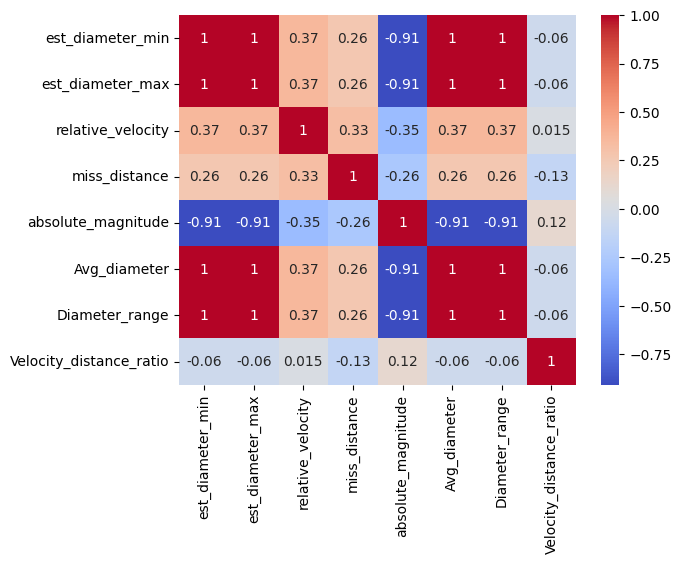

In [20]:
sns.heatmap(
    x.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [21]:
corr_matrix = x.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


In [22]:
to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Drop Columns:", to_drop)

X = x.drop(columns=to_drop)

Drop Columns: ['est_diameter_max', 'absolute_magnitude', 'Avg_diameter', 'Diameter_range']


## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((72663, 4), (18166, 4), (72663,), (18166,))

## Feature Scaling

In [25]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [26]:
x_train_scaled

array([[-0.74679691,  0.08131269, -1.36658496,  0.00179327],
       [-0.80979067, -0.03220487,  0.72186099, -0.08128653],
       [-0.04385342,  0.17540828, -0.38786429, -0.06958398],
       ...,
       [ 0.29415524,  0.29166312,  0.18307785, -0.07573583],
       [ 1.01158907,  1.05543701, -0.74058868, -0.04800079],
       [ 0.47588145,  0.96784764, -0.63804752, -0.05359429]],
      shape=(72663, 4))

In [27]:
x_test_scaled

array([[ 1.01158907,  1.71232968,  0.25414408, -0.06634816],
       [-0.75515273, -0.84505809,  1.54071378, -0.08749169],
       [ 0.47588145, -0.77702137,  1.54233546, -0.08720794],
       ...,
       [ 1.87754198, -1.14256882,  0.53852024, -0.08718143],
       [-0.59461582,  0.94691296,  0.99118745, -0.07741856],
       [ 0.40016548,  0.04119014, -0.00345107, -0.07592102]],
      shape=(18166, 4))

## Feature Selection Using RFE

In [28]:
rf = RandomForestClassifier(random_state=42)

In [29]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
rfe = RFE(
    estimator=rf,
    n_features_to_select=5
)

In [31]:
rfe

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [32]:
rfe.fit(x_train_scaled, y_train)

C:\Users\SAMI\anaconda3\envs\ml_env\Lib\site-packages\sklearn\feature_selection\_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=4. There will be no feature selection and all features will be kept.
  warnings.warn(


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [33]:
rfe.support_

array([ True,  True,  True,  True])

In [34]:
selected_features = X.columns[rfe.support_]

In [35]:
selected_features

Index(['est_diameter_min', 'relative_velocity', 'miss_distance',
       'Velocity_distance_ratio'],
      dtype='str')

In [36]:
x_train_selected = rfe.transform(x_train_scaled)

In [37]:
x_train_selected

array([[-0.74679691,  0.08131269, -1.36658496,  0.00179327],
       [-0.80979067, -0.03220487,  0.72186099, -0.08128653],
       [-0.04385342,  0.17540828, -0.38786429, -0.06958398],
       ...,
       [ 0.29415524,  0.29166312,  0.18307785, -0.07573583],
       [ 1.01158907,  1.05543701, -0.74058868, -0.04800079],
       [ 0.47588145,  0.96784764, -0.63804752, -0.05359429]],
      shape=(72663, 4))

In [38]:
x_test_selected = rfe.transform(x_test_scaled)

In [39]:
x_test_selected

array([[ 1.01158907,  1.71232968,  0.25414408, -0.06634816],
       [-0.75515273, -0.84505809,  1.54071378, -0.08749169],
       [ 0.47588145, -0.77702137,  1.54233546, -0.08720794],
       ...,
       [ 1.87754198, -1.14256882,  0.53852024, -0.08718143],
       [-0.59461582,  0.94691296,  0.99118745, -0.07741856],
       [ 0.40016548,  0.04119014, -0.00345107, -0.07592102]],
      shape=(18166, 4))

## Hyperparameter Tuning

In [40]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [41]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [42]:
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [43]:
grid_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [45]:
grid_search.best_params_

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

## Build Final Model

In [46]:
final_model = grid_search.best_estimator_

In [47]:
y_pred = final_model.predict(x_test_selected)

In [48]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(18166,))

In [49]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [50]:
accuracy

0.9151711989430805

In [51]:
precision = precision_score(
    y_test,
    y_pred
)

In [52]:
precision

0.6805111821086262

In [53]:
recall = recall_score(
    y_test,
    y_pred
)

In [54]:
recall

0.24108658743633277

In [55]:
f1 = f1_score(
    y_test,
    y_pred
)

In [56]:
f1

0.3560384454659423

In [57]:
cm = confusion_matrix(
    y_test,
    y_pred
)

In [58]:
cm

array([[16199,   200],
       [ 1341,   426]])

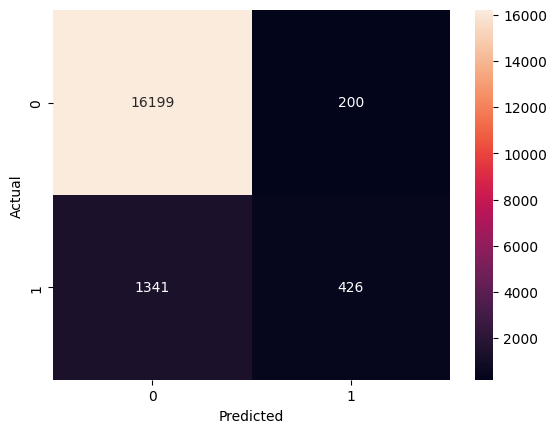

In [59]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

In [60]:
importance = final_model.feature_importances_

In [61]:
importance

array([0.43462887, 0.17088541, 0.20424175, 0.19024397])

In [62]:
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
})

In [63]:
feature_importance

,Feature,Importance
0,est_diameter_min,0.434629
1,relative_velocity,0.170885
2,miss_distance,0.204242
3,Velocity_distance_ratio,0.190244


In [64]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [65]:
feature_importance

,Feature,Importance
0,est_diameter_min,0.434629
2,miss_distance,0.204242
3,Velocity_distance_ratio,0.190244
1,relative_velocity,0.170885


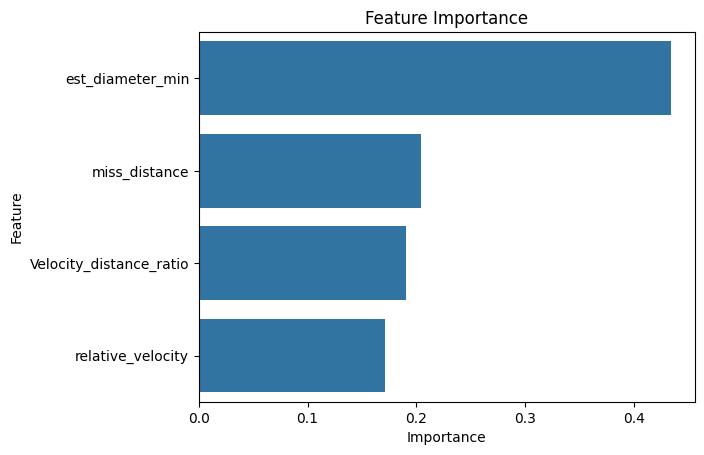

In [66]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

### Final Conclusion 
The Random Forest Classifier was chosen as the final model because it outperformed all previously tested algorithms. After hyperparameter tuning using GridSearchCV, the model achieved 91.5% accuracy. The model effectively distinguishes hazardous and non-hazardous Near-Earth Objects and demonstrates strong predictive performance on unseen data. Feature importance analysis revealed that asteroid diameter, miss distance, and velocity are the key factors influencing hazard classification.